# Make several plots comparing different results

In [149]:
main_llm_dir = '/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/'
# which specific subdirectories do we want to parse?
dirs_to_use = ['chatgpt_api/', 'chatgpt_api_highR_lowVerbose/', 'chatgpt_api_highR_lowVerbose_mini/', 'gemini/', 'claude_haiku/', 'claude_haiku_thinking/']

# low-tier
dirs_to_use = ['chatgpt_api/', 'gemini/', 'claude_haiku/']

# mid-to-high tier
dirs_to_use = ['chatgpt_api_highR_lowVerbose/', 'claude_haiku_thinking_maxT8000/', 'chatgpt_api_highR_lowVerbose_mini/']


# full baseline data stored
dir_jsons = '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/qa_jsons/'

save_fig_dir = '/Users/jnaiman/Dropbox/jcdl_followup/paper_figures/'

In [150]:
from glob import glob
import pickle
import pandas as pd
import json
from copy import deepcopy
import numpy as np
import os
import matplotlib.pyplot as plt
from Levenshtein import distance as levenshtein_distance # Assuming you have python-Levenshtein installed
import seaborn as sns


# debug
from importlib import reload

import seaborn as sns
import numpy as np

In [151]:
def track_questions(questions_figure, df, df_question_tags, ignore_special = False):
    df_F_question_tags = {}
    for k,v in df_question_tags.items():
        df_F_question_tags[k] = []
    # also track questions
    for qa in questions_figure:
        if ignore_special and qa['type'] == 'special':
            continue
        dfsub = df[df['question']==qa['question']]
        df_F_question_tags['tag'].append(qa['tag'].replace('#', '\\#'))
        df_F_question_tags['question'].append(qa['question'].replace('#', '\\#'))
        level = np.unique(dfsub['Level'])[0].split('Level')[-1].replace(' ','')
        df_F_question_tags['Level'].append(level)
        ltype = np.unique(dfsub['Level Type'])[0].split('-level questions')[0]
        df_F_question_tags['Type'].append(ltype)
    return df_F_question_tags

In [152]:
import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import get_dirs_names_files

dirnames, dirs, files_parsed = get_dirs_names_files(main_llm_dir, 
        dirs_to_use, 
        replace_names = {'chatgpt_api':'ChatGPT', 
                        'chatgpt_api_highR_lowVerbose':'ChatGPT-HR',
                        'chatgpt_api_highR_lowVerbose_mini':'ChatGPT-HR-mini', 
                        'gemini':'Gemini', 
                        'claude_haiku':'Claude', 
                        'claude_haiku_thinking':'Claude-T-Low',
                        'claude_haiku_thinking_maxT8000':'Claude-T'
                        },
        verbose=True)

# dirs_tmp = glob(main_llm_dir + '*')
# dirs_tmp

DIRS:
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet_maxtoken8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_mini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_old
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking_maxT8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose_mini

ONLY USED DIRNAMES, DIRS
ChatGPT-HR ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose/
Claude-T ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking_maxT8000/
ChatGPT-HR-mini ,  /U

In [153]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import parse_json_files, fix_aspect

df = parse_json_files(dirnames, dirs, files_parsed, dir_jsons, 
                     verbose=True, use_explanation=True)
print("!!!!!!!! DONE LOADING !!!!!!!!!!!")


****************************************
*********** ChatGPT-HR ****************
****************************************

----------- Picture_000194_qa.pickle ------------
[ERROR]: missing key: line styles
  question format: Please format the output as a json as {"line styles":[]}, where each element of the list refers to the linestyle of each line in the figure panel in the form a matplotlib linestyle type.
  GT: {'line styles': ['-', ':', ':', '-', '-', '-', '-', '-', '-']}
  LMM: {}
  raw LMM: PARSE_ERROR

----------- Picture_000032_qa.pickle ------------
----------- Picture_000102_qa.pickle ------------
----------- Picture_000031_qa.pickle ------------
----------- Picture_000160_qa.pickle ------------
----------- Picture_000198_qa.pickle ------------
----------- Picture_000089_qa.pickle ------------
----------- Picture_000030_qa.pickle ------------
----------- Picture_000094_qa.pickle ------------
----------- Picture_000120_qa.pickle ------------
----------- Picture_000095_qa.pic

<unknown>:3: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2: SyntaxWarning: invalid escape sequence '\o'


[WARNING]: updated LMM key -- was "plot_style", assuming "plot style"
[WARNING]: updated LMM key -- was "median_x", assuming "median x"
----------- Picture_000080_qa.pickle ------------
[WARNING]: updated LMM key -- was "plot_style", assuming "plot style"
[WARNING]: updated LMM key -- was "plot_types", assuming "plot types"
[WARNING]: updated LMM key -- was "line_styles", assuming "line styles"
[ERROR]: missing key: mean y
  question format: Please format the output as a json as {"mean y":""} for this figure panel, where the "mean y" value should be a float, calculated from the data values used to create the plot.
  GT: {'mean y': -2847.122417851258}
  LMM: {}
  raw LMM: PARSE_ERROR

[WARNING]: updated LMM key -- was "median_color", assuming "median color"
[WARNING]: updated LMM key -- was "distribution_color", assuming "distribution color"
----------- Picture_000143_qa.pickle ------------
[WARNING]: updated LMM key -- was "plot_style", assuming "plot style"
[WARNING]: updated LMM key 

In [154]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type,Explanation
0,Picture_000194_qa,NaN,None,How many panels are in this figure?,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,"{'nrows': 2, 'ncols': 1}","{'nrows': 2, 'ncols': 1}",Level 1,Figure-level questions,{'explanation': 'The figure contains two disti...
1,Picture_000194_qa,NaN,None,What is the plot style used in this figure?,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'plot style': 'classic'},{'plot style': 'default'},Level 1,Figure-level questions,{'explanation': 'The figure uses a plain white...
2,Picture_000194_qa,NaN,None,What is the colormap that was used in this fig...,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'colormap': 'rainbow'},{'colormap': 'viridis'},Level 1,Figure-level questions,{'explanation': 'The figure uses many distinct...
3,Picture_000194_qa,NaN,None,What is the aspect ratio of this figure?,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'aspect ratio': 0.75},{'aspect ratio': 1.3220519588807769},Level 1,Figure-level questions,{'explanation': 'The overall figure image is i...
4,Picture_000194_qa,NaN,None,What are the titles for each figure panel?,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,"{'titles': ['TIMESCALE $k = 0.001\,\mathrm{cm}...","{'titles': ['', '']}",Level 1,Figure-level questions,{'explanation': 'The figure is arranged as two...


In [155]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import get_lmm_gt

df_question_tags = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags[t] = []

# Figure-level Questions

In [156]:
figure_level_questions = df[df['Level Type']=='Figure-level questions']['question'].unique()
#figure_level_questions1 = df[df['Level Type']=='Figure-level questions']['question'].unique()
# # filter out addition of numbers/lists
# figure_level_questions = []
# for f in figure_level_questions1:
#     if 'Please choose from ' in f:
#         figure_level_questions.append(f.split('Please choose from ')[0].rstrip().lstrip())
#     else:
#         figure_level_questions.append(f)
# figure_level_questions = np.unique(figure_level_questions).tolist()
figure_level_questions

array(['How many panels are in this figure?',
       'What is the plot style used in this figure?',
       'What is the colormap that was used in this figure?',
       'What is the aspect ratio of this figure?',
       'What are the titles for each figure panel?',
       'What are the x-axis titles for each figure panel?',
       'What are the y-axis titles for each figure panel?',
       'What are the values for each of the tick marks on the x-axis?',
       'What are the values for each of the tick marks on the y-axis?',
       'What are the plot types for each panel in the figure?',
       'Which plot shows the largest median data values?',
       'Which plot shows the strongest linear relationship between its x and y values?'],
      dtype=object)

Of these, which do we want to calculate accuracies for, and how should accuracies be calculated?

In [157]:
questions_figure = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'}, # have to calculate this from answer
    {'tag':'plot style', 'question':'What is the plot style used in this figure?', 'type':'binary string'},
    {'tag':'plot type', 'question':'What are the plot types for each panel in the figure?', 'type':'binary string list', 'use list':True, 'use bar':True},
    {'tag':'colormap', 'question':'What is the colormap that was used in this figure?', 'type':'binary string'},
    {'tag':'aspect ratio', 'question':'What is the aspect ratio of this figure?', 'type':'float'},
    {'tag':'titles', 'question': 'What are the titles for each figure panel?', 'type':'string list', 'use cer':True},
    {'tag':'x-labels', 'question': 'What are the x-axis titles for each figure panel?', 'type':'string list'},
    {'tag':'y-labels', 'question': 'What are the y-axis titles for each figure panel?', 'type':'string list'},
    # {'tag':'largest median', 'question':'Which plot shows the largest median data values?', 'type':'float'},
    # {'tag':'strongest linear', 'question':'Which plot shows the strongest linear relationship between its x and y values?', 'type':'float'},
]

In [158]:
reload(utils.results_plotting_utils)
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt
from utils.results_plotting_utils import calculate_plot_accuracies

df_F_question_tags, dfplot1 = calculate_plot_accuracies(df,questions_figure, df_question_tags)

[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align


How many answers do we have per number of panels per figure?

In [159]:
dfpsort = dfplot1['# panels GT'].value_counts().sort_index()
dfpsort

# panels GT
1     118
2      32
3       9
4      17
5       5
6       3
8       8
9       2
12      3
15      2
20      1
Name: count, dtype: int64

For plotting, w/rt ground truth # of panels only take ones where count = X or more

In [160]:
count_cut = 2
panels_cut = dfpsort[dfpsort >= count_cut].index
print('only these panels:', np.array(panels_cut.values))

dfcut = dfplot1.copy()#[dfplot[dfplot['# panels GT']] >= panels_cut.max()]
dfcut = dfcut[dfcut['# panels GT'].isin(panels_cut)]
dfcut.head()

only these panels: [ 1  2  3  4  5  6  8  9 12 15]


,Tag,# panels GT,ChatGPT-HR # panels,Claude-T # panels,ChatGPT-HR-mini # panels,ChatGPT-HR plot style,Claude-T plot style,ChatGPT-HR-mini plot style,ChatGPT-HR plot type,Claude-T plot type,...,ChatGPT-HR-mini aspect ratio,ChatGPT-HR titles,Claude-T titles,ChatGPT-HR-mini titles,ChatGPT-HR x-labels,Claude-T x-labels,ChatGPT-HR-mini x-labels,ChatGPT-HR y-labels,Claude-T y-labels,ChatGPT-HR-mini y-labels
0,# panels,2,2,2,2,0,0,0,1.0,1.0,...,0.800000,0.000000,0.000000,1.000000,0.467391,0.456522,0.923913,0.222222,0.888889,0.888889
1,# panels,4,4,4,4,0,0,0,1.0,1.0,...,0.250000,0.284091,0.306818,0.903226,0.295455,1.000000,1.000000,0.579710,0.449275,0.768116
2,# panels,1,1,1,1,0,0,0,1.0,1.0,...,1.530000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.642857,1.000000,1.000000
3,# panels,1,1,1,1,0,0,0,1.0,1.0,...,1.360000,1.000000,1.000000,1.000000,0.263158,0.894737,0.789474,1.000000,1.000000,1.000000
4,# panels,1,1,1,1,0,0,0,1.0,1.0,...,0.703125,1.000000,1.000000,1.000000,0.696970,0.696970,0.848485,0.324324,0.513514,0.648649


In [161]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks

marker_sizes, marker_styles, colors, labels = create_output_marks(df, marker_min=20, marker_max=70)

In [162]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import make_square_grid_figure, make_square_grid_figure_gs

In [163]:
dfplot1.columns

Index(['Tag', '# panels GT', 'ChatGPT-HR # panels', 'Claude-T # panels',
       'ChatGPT-HR-mini # panels', 'ChatGPT-HR plot style',
       'Claude-T plot style', 'ChatGPT-HR-mini plot style',
       'ChatGPT-HR plot type', 'Claude-T plot type',
       'ChatGPT-HR-mini plot type', 'ChatGPT-HR colormap', 'Claude-T colormap',
       'ChatGPT-HR-mini colormap', 'ChatGPT-HR aspect ratio',
       'Claude-T aspect ratio', 'ChatGPT-HR-mini aspect ratio',
       'ChatGPT-HR titles', 'Claude-T titles', 'ChatGPT-HR-mini titles',
       'ChatGPT-HR x-labels', 'Claude-T x-labels', 'ChatGPT-HR-mini x-labels',
       'ChatGPT-HR y-labels', 'Claude-T y-labels', 'ChatGPT-HR-mini y-labels'],
      dtype='object')

In [164]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import add_kde_contours

In [165]:
# counts = pd.DataFrame({m: [v.sum(), len(v) - v.sum()] 
#                         for m, v in results.items()}, 
#                        index=['Correct', 'Incorrect'])
# counts.T.plot(kind='bar', stacked=True, color=['steelblue','salmon'], figsize=(7,4))

In [166]:
# pivot = df.pivot(index='Model', columns='N_panels', values='Accuracy')
# sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)

/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:345: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig, axes


use cer


SystemExit: 

/opt/anaconda3/envs/JCDL2025/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


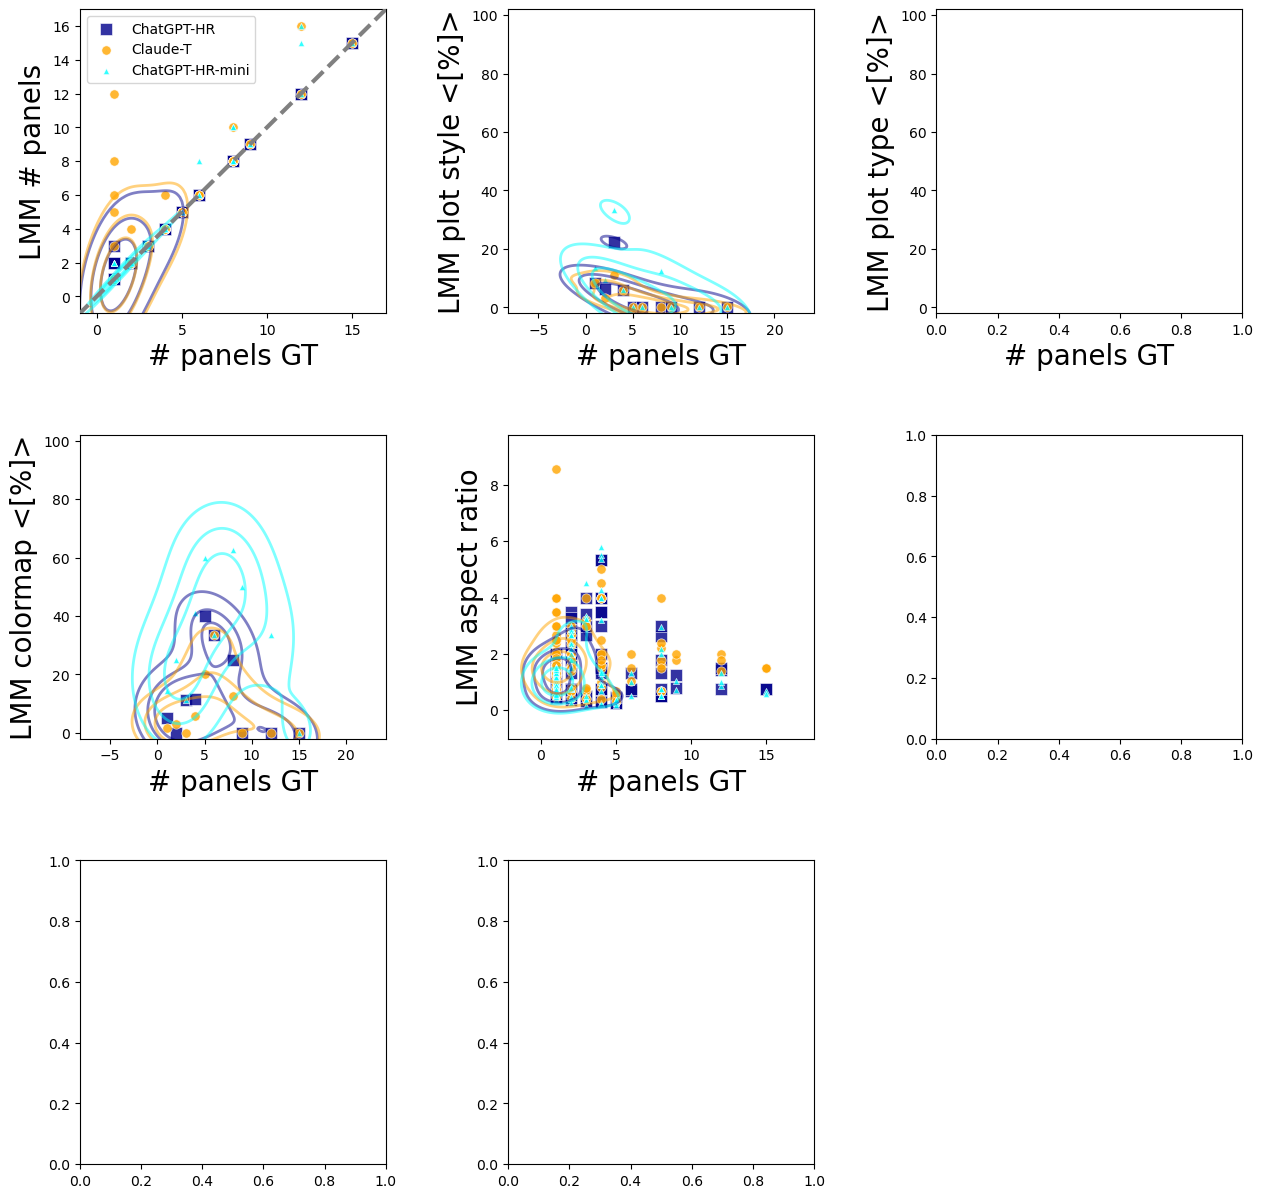

In [168]:
fixed_axis = '# panels GT'

base = 5
#nx = 1; ny = 3
#npanels = nx*ny
#fig, axes = plt.subplots(1,npanels, figsize=(base*npanels,base))
levels = [0.25, 0.5, 0.75]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

plot_kde = True

# for plotting
dfplot = dfcut.copy()

fudge = 2

iqset = 0
plot_diffs = False
normalize_diff = False

questions_plot = questions_figure

specials = ['aspect ratio']
use_average_percent = True


fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))
counts_df = {}

for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]
    counts_df[q['tag']] = {'use bar':False, 'df':{}, 'panel':-1}

    for imodel, model in enumerate(dfsub['model'].unique()):

        #gttag = '# panels GT' # for fixed axis
        if fixed_axis is not None:
            gttag = fixed_axis
        lmtag = labels[model] + ' ' + q['tag'] 
        if 'yfudge' not in q:
            q = deepcopy(q)
            q['yfudge'] = fudge
        if 'xfudge' not in q:
            q['xfudge'] = fudge
        gt = dfplot[gttag]
        lmm = dfplot[lmtag]

        if 'use cer' in q:
            print('use cer')
            import sys; sys.exit()

        ylabel_tag = 'LMM ' + q['tag']

        useBar = False
        if 'string' in q['type']: # convert to %
            lmm *= 100
            if not use_average_percent:
                ylabel_tag += ' [%]'
            # elif 'use bar' in q:
            #     if q['use bar']:
            #         ylabel_tag += ' [%]'
            #         useBar = True
            #         counts_df[q['tag']]['use bar'] = True
            #         # fill counts
            #         counts_df[q['tag']]['df'][model] = []
            #         import sys; sys.exit()
            else:
                ylabel_tag += ' <[%]>'
                lmm = dfplot.groupby(gttag)[lmtag].mean().reset_index()[lmtag]
                gt = dfplot.groupby(gttag)[lmtag].mean().reset_index()[gttag]
                if 'use bar' in q:
                    if q['use bar']:
                        counts_df[q['tag']]['use bar'] = True
                        counts_df[q['tag']]['panel'] = iq
                        useBar = True
                        # print('Double check this calculation!')
                        # import sys; sys.exit()
                        for cname in ['Model', gttag, 'Accuracy <[%]>']:
                            if cname not in counts_df[q['tag']]['df']:
                                counts_df[q['tag']]['df'][cname] = []
                        counts_df[q['tag']]['df']['Model'].extend(np.repeat(model,len(gt)))
                        counts_df[q['tag']]['df'][gttag].extend(deepcopy(gt))
                        counts_df[q['tag']]['df']['Accuracy <[%]>'].extend(deepcopy(lmm))

        if useBar:
            continue
                
        if iq == iqset:
            add_kde_contours(axes[iq], gt, lmm, colors[model], 
                                labels[model], marker_styles[model], marker_sizes[model], 
                                levels=levels, plot_kde=plot_kde)
        else:
            add_kde_contours(axes[iq], gt, lmm, colors[model], 
                                None, marker_styles[model], marker_sizes[model], 
                                levels=levels, plot_kde=plot_kde)
    axes[iq].set_xlabel(gttag, fontsize=fontsize)
    axes[iq].set_ylabel(ylabel_tag, fontsize=fontsize)

    if not plot_diffs and q['tag'] not in specials and 'string' not in q['type']:
        axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                        color=eq_linecolor)
        axes[iq].set_ylabel(ylabel_tag, fontsize=fontsize)
        if 'string' not in q['type'] and q['tag'] not in specials:
            axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
        else:
            axes[iq].set_ylim(np.min(lmm)-q['yfudge'], np.max(lmm)+q['yfudge'])
        axes[iq].set_xlim(np.min(gt)-q['xfudge'], np.max(gt)+q['xfudge'])

    # for percentages
    if 'string' in q['type']:
        axes[iq].set_ylim(0-q['yfudge'], 100+q['yfudge'])

    axes[iqset].legend()

# go back and plot all models-things
for k,d in counts_df.items():
    if d['use bar']:
        dfc = pd.DataFrame(d['df'])
        cgt = dfc.columns[~dfc.columns.isin(['Model','Accuracy <[%]>'])][0]
        pivot = dfc.pivot(index='Model', columns=cgt, values='Accuracy <[%]>')
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100, ax=axes[d['panel']], annot_kws={'size': 6})
        axes[d['panel']].set_ylabel('LMM '+k)
        cbar = axes[d['panel']].collections[0].colorbar
        cbar.set_label('Accuracy <[%]>', fontsize=12, labelpad=10)


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)


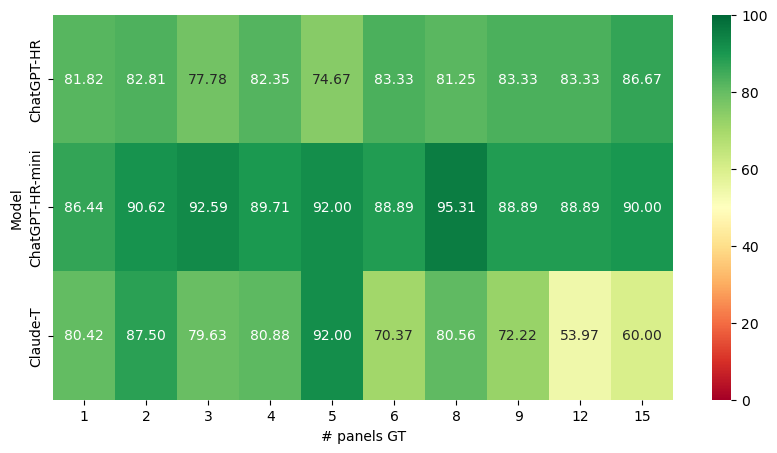

In [148]:
fig,ax = plt.subplots(figsize=(10,5))

for k,d in counts_df.items():
    if d['use bar']:
        dfc = pd.DataFrame(d['df'])
        cgt = dfc.columns[~dfc.columns.isin(['Model','Accuracy <[%]>'])][0]
        pivot = dfc.pivot(index='Model', columns=cgt, values='Accuracy <[%]>')
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=100, ax=ax)

In [121]:
len(dfc['Model']), len(dfc['# panels GT']), len(dfc['Accuracy <[%]>'])

(30, 30, 30)

## Plot-level

In [122]:
# by number of item
questions_figure_plots = [
    {'tag':'# bars', 'question':'How many bars are there in the specified figure panel?', 'type':'float', 'yfudge':5},
    {'tag':'# scatters', 'question':'How many scatter points are there in the specified figure panel?', 
        'type':'float', 'yfudge':10, 'xlim':(0,150)},
    {'tag':'# lines', 'question':'How many lines are there in the specified figure panel?', 'type':'float', 'yfudge':2},
    {'tag':'min data','question':'What is the minimum value of the data in this figure panel?', 'type':'float',  'norm':'diff'},#, 'xscale':'log'}
    {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'color-mean data','question':'What is the mean value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'y-med data','question':'What is the median value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'color-med data','question':'What is the median value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
]

df_question_tags_plots = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags_plots[t] = []

In [123]:
df[df['Level Type']=='Plot-level questions']['question'].unique()

array(['What are the matplotlib linestyles in this figure panel?',
       'How many bars are there in the specified figure panel?',
       'How many lines are there in the specified figure panel?',
       'What is the maximum value of the data in this figure panel?',
       'What is the maximum value of the data along the x-axis in this figure panel?',
       'What is the mean value of the data in this figure panel?',
       'What is the mean value of the data along the x-axis in this figure panel?',
       'What is the median value of the data in this figure panel?',
       'What is the median value of the data along the x-axis in this figure panel?',
       'What is the minimum value of the data in this figure panel?',
       'What is the minimum value of the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the y-axis in this figure panel?',
       'What is th

/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()   # now works without warnings


# bars
# scatters
# lines
min data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 4
  the number of NaNs for model ChatGPT-HR-mini = 0
x-mean data
  the number of NaNs for model ChatGPT-HR = 45
  the number of NaNs for model Claude-T = 48
  the number of NaNs for model ChatGPT-HR-mini = 20
y-mean data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model ChatGPT-HR-mini = 0
color-mean data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 2
  the number of NaNs for model ChatGPT-HR-mini = 0
x-med data
  the number of NaNs for model ChatGPT-HR = 20
  the number of NaNs for model Claude-T = 45
  the number of NaNs for model ChatGPT-HR-mini = 57
y-med data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model ChatGPT-HR-mini = 0
color-med data
  the number of NaNs for model ChatG

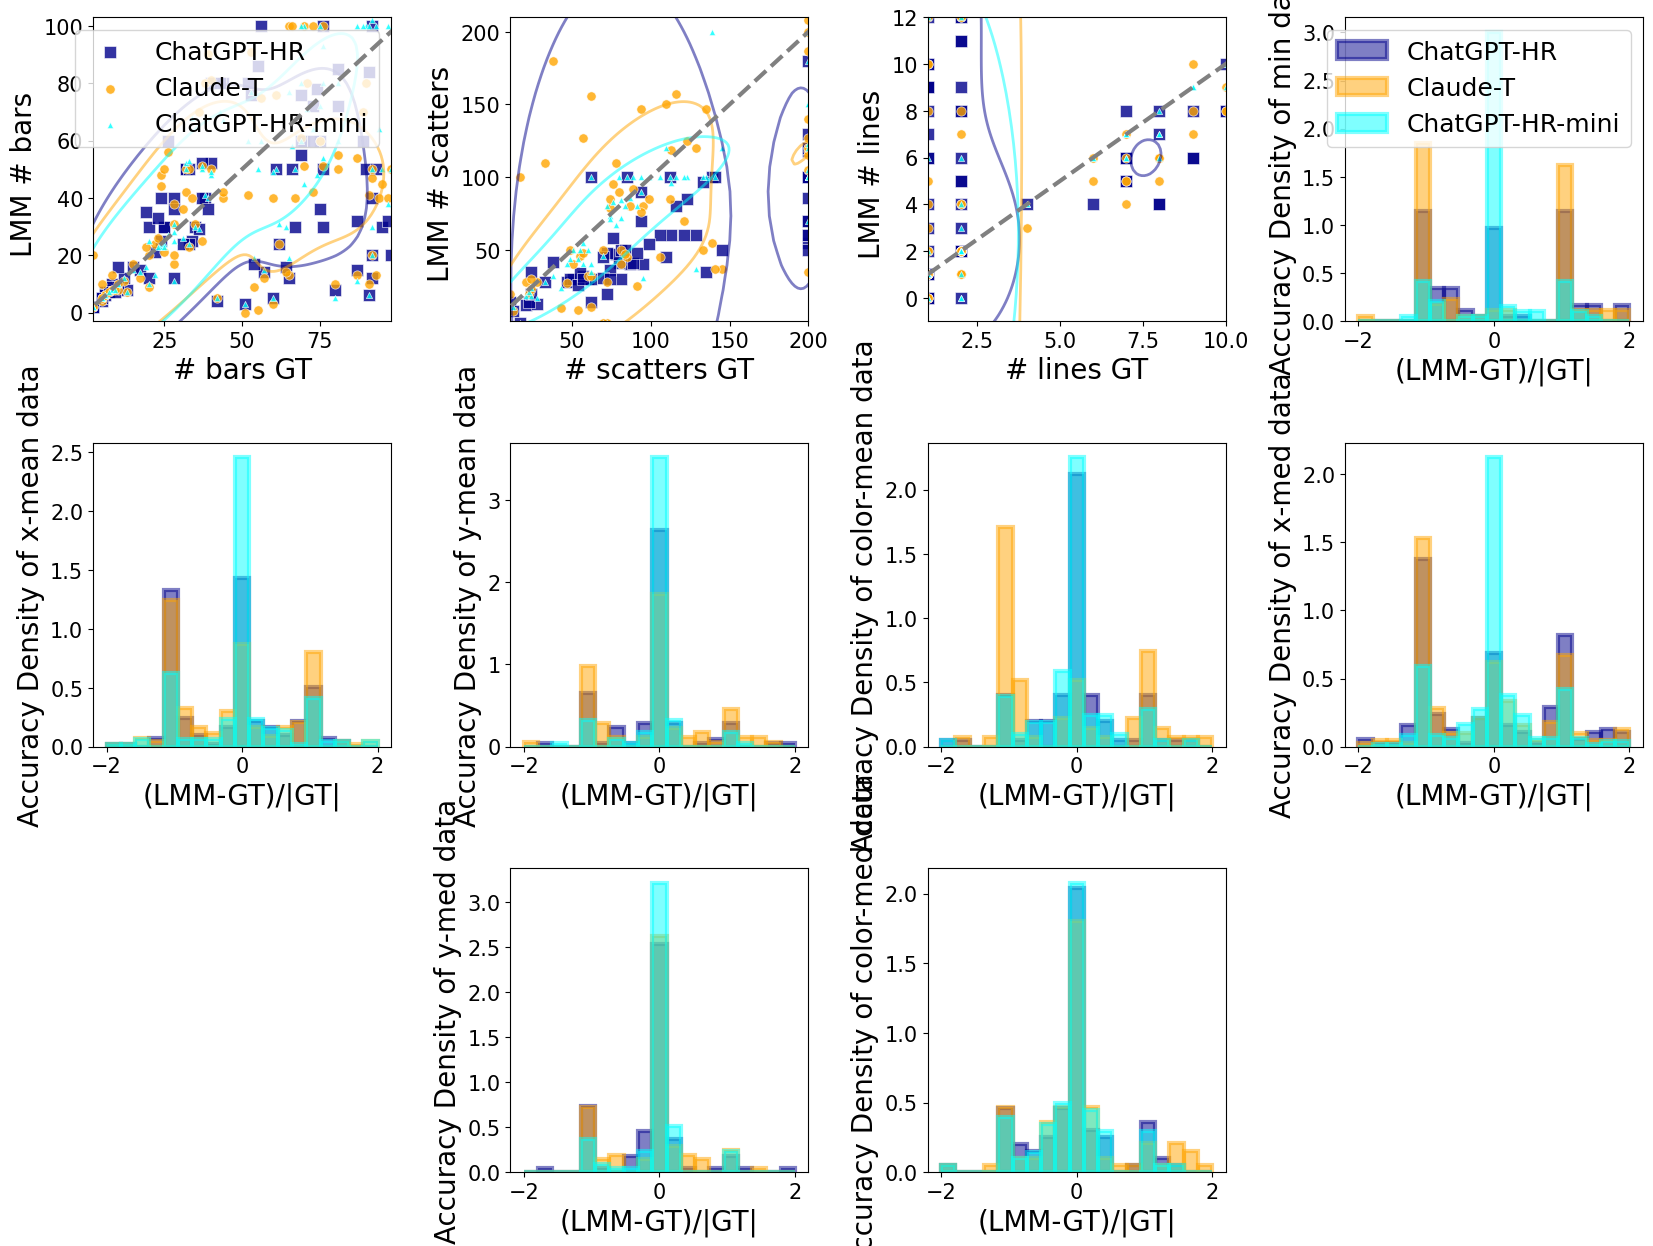

In [124]:
ylims = {'# bars': (-100,100), '# scatters':(-100,100), '# lines':(-10,10)}
questions_plot = questions_figure_plots

import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt

base = 5
nx = 1; ny = 3
npanels = nx*ny
fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))

levels = [0.5]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3

iqset = 0
plot_diffs = False
normalize_diff = False
take_abs = True

hasHistLegend = False
for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]
    print(q['tag'])
    for imodel, model in enumerate(dfsub['model'].unique()):
        dfsub2 = dfsub[dfsub['model']==model]
        gt, lmm1 = get_lmm_gt(dfsub2, q['type'],verbose=False)
        gttag = q['tag']+' GT'
        lmtag = labels[model]
        # if plot_diffs:
        #     lmm = (lmm1-gt)
        #     if normalize_diff:
        #         lmm = lmm/gt
        # else:
        lmm = deepcopy(lmm1)
        lmtag_adder = ''
        diffnorm = False
        if 'norm' in q:
            if 'diff':
                if take_abs:
                    lmm = (lmm-gt)/np.abs(gt)
                    lmtag_adder = '(LMM-GT)/|GT|'
                else:
                    lmm = (lmm-gt)/gt
                    lmtag_adder = '(LMM-GT)/GT'

                diffnorm = True
        dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
        if iq == iqset:
            add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             labels[model], marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
        else:
            if not diffnorm:
                add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             None, marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
            else:
                # dfsub2 = dfsub[dfsub['model']==model]
                # gt, lmm = get_lmm_gt(dfsub2, q['type'])
                # diff = (lmm-gt)/gt
                diff = dfplot[lmtag]
                # count NaNs
                print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
                axes[iq].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                            color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                            linewidth=hist_thick)
                axes[iq].set_xlabel(lmtag_adder, fontsize=fontsize)
                axes[iq].set_ylabel('Accuracy Density of '+q['tag'],  fontsize=fontsize)
                if not hasHistLegend:
                    axes[iq].legend()
                    hasHistLegend = True
    #if not plot_diffs:
    if 'yfudge' in q:
        if not diffnorm:
            axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                        color=eq_linecolor)
            axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
        # else:
        #     axes[iq].set_ylim([q['xlim'][0]-q['yfudge'], q['xlim'][1]+q['yfudge']])
    if not diffnorm:
        axes[iq].set_xlim(np.min(gt), np.max(gt))
        axes[iq].set_ylabel('LMM ' + q['tag'] + ' ' + lmtag_adder, fontsize=fontsize)
        axes[iq].set_xlabel(gttag, fontsize=fontsize)
    # if 'xscale' in q:
    #     axes[iq].set_xscale(q['xscale'])

axes[iqset].legend()


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)


## For particular kinds of plots

In [125]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt

def plot_specific_type(dfsubplot, questions_plot, base=7, levels = [0.5],
    fontsize = 20,
    tick_fontsize = 15,
    legend_fontsize = 18,
    eq_linethick = 3,
    eq_linestyle = '--',
    eq_linecolor = 'gray',     
    hmin = -2,
    hmax = 2,
    nbins = 20,
    alpha_hist = 0.5,
    hist_thick = 3, 
    plot_diffs = False,
    normalize_diff = False,
    take_abs = True, verbose=True
    ):

    #questions_plot = questions_figure_plots_contours
    #base = 7
    # nx = 1; ny = 3
    # npanels = nx*ny
    fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))

    hist_bins = np.linspace(hmin,hmax,nbins)

    iqset = 0

    hasHistLegend = False
    for iq,q in enumerate(questions_plot):
        print(q['tag'])
        dfsub = dfsubplot[dfsubplot['question']==q['question']]
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            gt, lmm1 = get_lmm_gt(dfsub2, q['type'], verbose=verbose)
            gttag = q['tag']+' GT'
            lmtag = labels[model]
            # if plot_diffs:
            #     lmm = (lmm1-gt)
            #     if normalize_diff:
            #         lmm = lmm/gt
            # else:
            lmm = deepcopy(lmm1)
            lmtag_adder = ''
            diffnorm = False
            if 'norm' in q:
                if 'diff':
                    if take_abs:
                        lmm = (lmm-gt)/np.abs(gt)
                        lmtag_adder = '(LMM-GT)/|GT|'
                    else:
                        lmm = (lmm-gt)/gt
                        lmtag_adder = '(LMM-GT)/GT'

                    diffnorm = True
            dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
            if iq == iqset and not diffnorm:
                add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                                labels[model], marker_styles[model], marker_sizes[model], 
                                levels=levels, plot_kde=plot_kde)
            else:
                if not diffnorm:
                    add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                                None, marker_styles[model], marker_sizes[model], 
                                levels=levels, plot_kde=plot_kde)
                else:
                    # dfsub2 = dfsub[dfsub['model']==model]
                    # gt, lmm = get_lmm_gt(dfsub2, q['type'])
                    # diff = (lmm-gt)/gt
                    diff = dfplot[lmtag]
                    # count NaNs
                    print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
                    axes[iq].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                                color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                                linewidth=hist_thick)
                    axes[iq].set_xlabel(lmtag_adder, fontsize=fontsize)
                    axes[iq].set_ylabel('Accuracy Density of '+q['tag'],  fontsize=fontsize)
                    if not hasHistLegend:
                        axes[iq].legend()
                        hasHistLegend = True
        #if not plot_diffs:
        if 'yfudge' in q:
            if not diffnorm:
                axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                            [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                            linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                            color=eq_linecolor)
                axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
            # else:
            #     axes[iq].set_ylim([q['xlim'][0]-q['yfudge'], q['xlim'][1]+q['yfudge']])
        if not diffnorm:
            axes[iq].set_xlim(np.min(gt), np.max(gt))
            axes[iq].set_ylabel('LMM ' + q['tag'] + ' ' + lmtag_adder, fontsize=fontsize)
            axes[iq].set_xlabel(gttag, fontsize=fontsize)
        # if 'xscale' in q:
        #     axes[iq].set_xscale(q['xscale'])

    axes[iqset].legend()


    # set font sizes
    for ax in axes:
        # Set tick label font sizes for second subplot
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        legend = ax.get_legend()
        if legend is not None:
            # Set legend font size for second subplot
            ax.legend(fontsize=legend_fontsize)

    return fig, axes

### Contours

In [126]:
# by number of item
questions_figure_plots_contours = [
    {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'color-mean data','question':'What is the mean value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'y-med data','question':'What is the median value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'color-med data','question':'What is the median value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
]

df_question_tags_plots_contours = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags_plots_contours[t] = []

In [127]:
# subset for a specific type
dfsubplot = df.copy()[df['plot type']=='contour']
#dfsubplot.head()

/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()   # now works without warnings


x-mean data
  the number of NaNs for model ChatGPT-HR = 9
  the number of NaNs for model Claude-T = 4
  the number of NaNs for model ChatGPT-HR-mini = 2
y-mean data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model ChatGPT-HR-mini = 0
color-mean data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model ChatGPT-HR-mini = 0
x-med data
  the number of NaNs for model ChatGPT-HR = 2
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model ChatGPT-HR-mini = 5
y-med data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model ChatGPT-HR-mini = 0
color-med data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model ChatGPT-HR-mini = 0


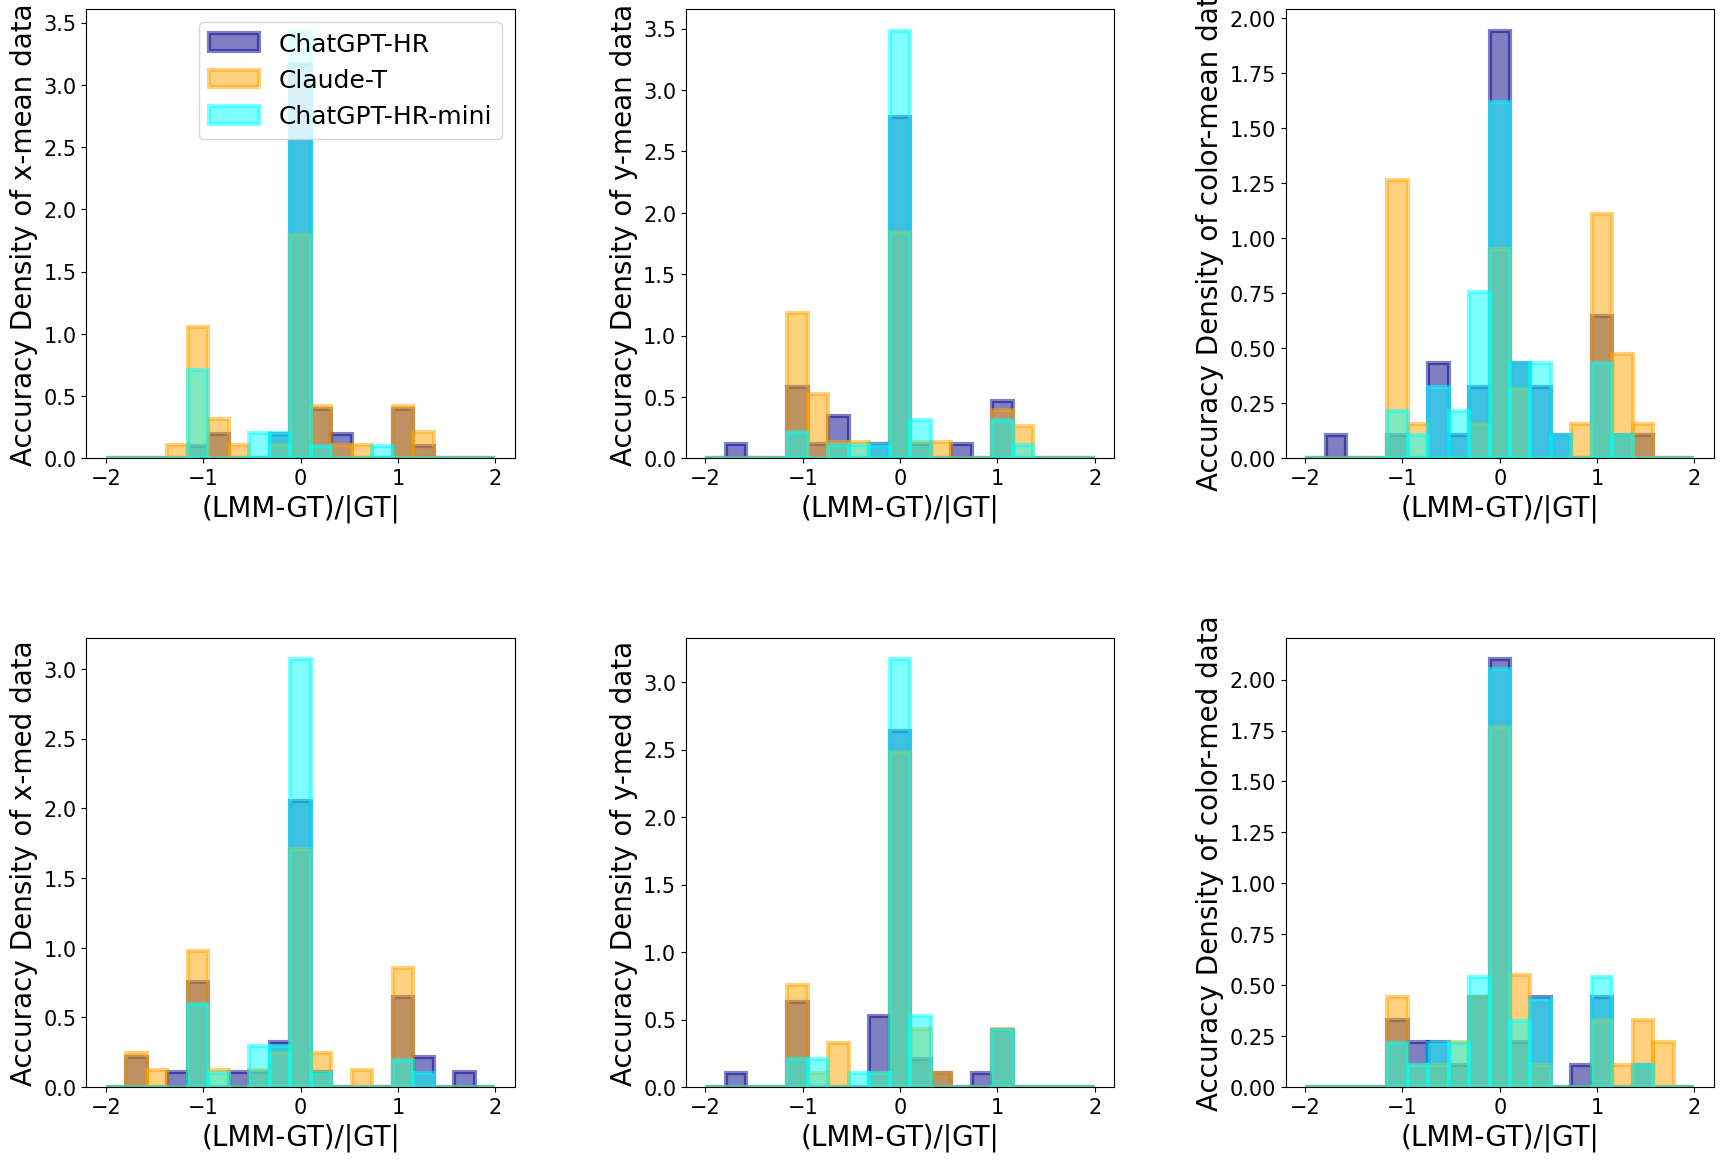

In [128]:
fig, axes = plot_specific_type(dfsubplot, questions_figure_plots_contours, verbose=False)

### Scatters

In [129]:
dfsubplot_sc = df.copy()[df['plot type']=='scatter']

x-mean data
  the number of NaNs for model ChatGPT-HR = 6
  the number of NaNs for model Claude-T = 23
  the number of NaNs for model ChatGPT-HR-mini = 1
y-mean data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model ChatGPT-HR-mini = 0
color-mean data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model ChatGPT-HR-mini = 0
x-med data
  the number of NaNs for model ChatGPT-HR = 3
  the number of NaNs for model Claude-T = 2
  the number of NaNs for model ChatGPT-HR-mini = 2
y-med data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model ChatGPT-HR-mini = 0
color-med data
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model ChatGPT-HR-mini = 0


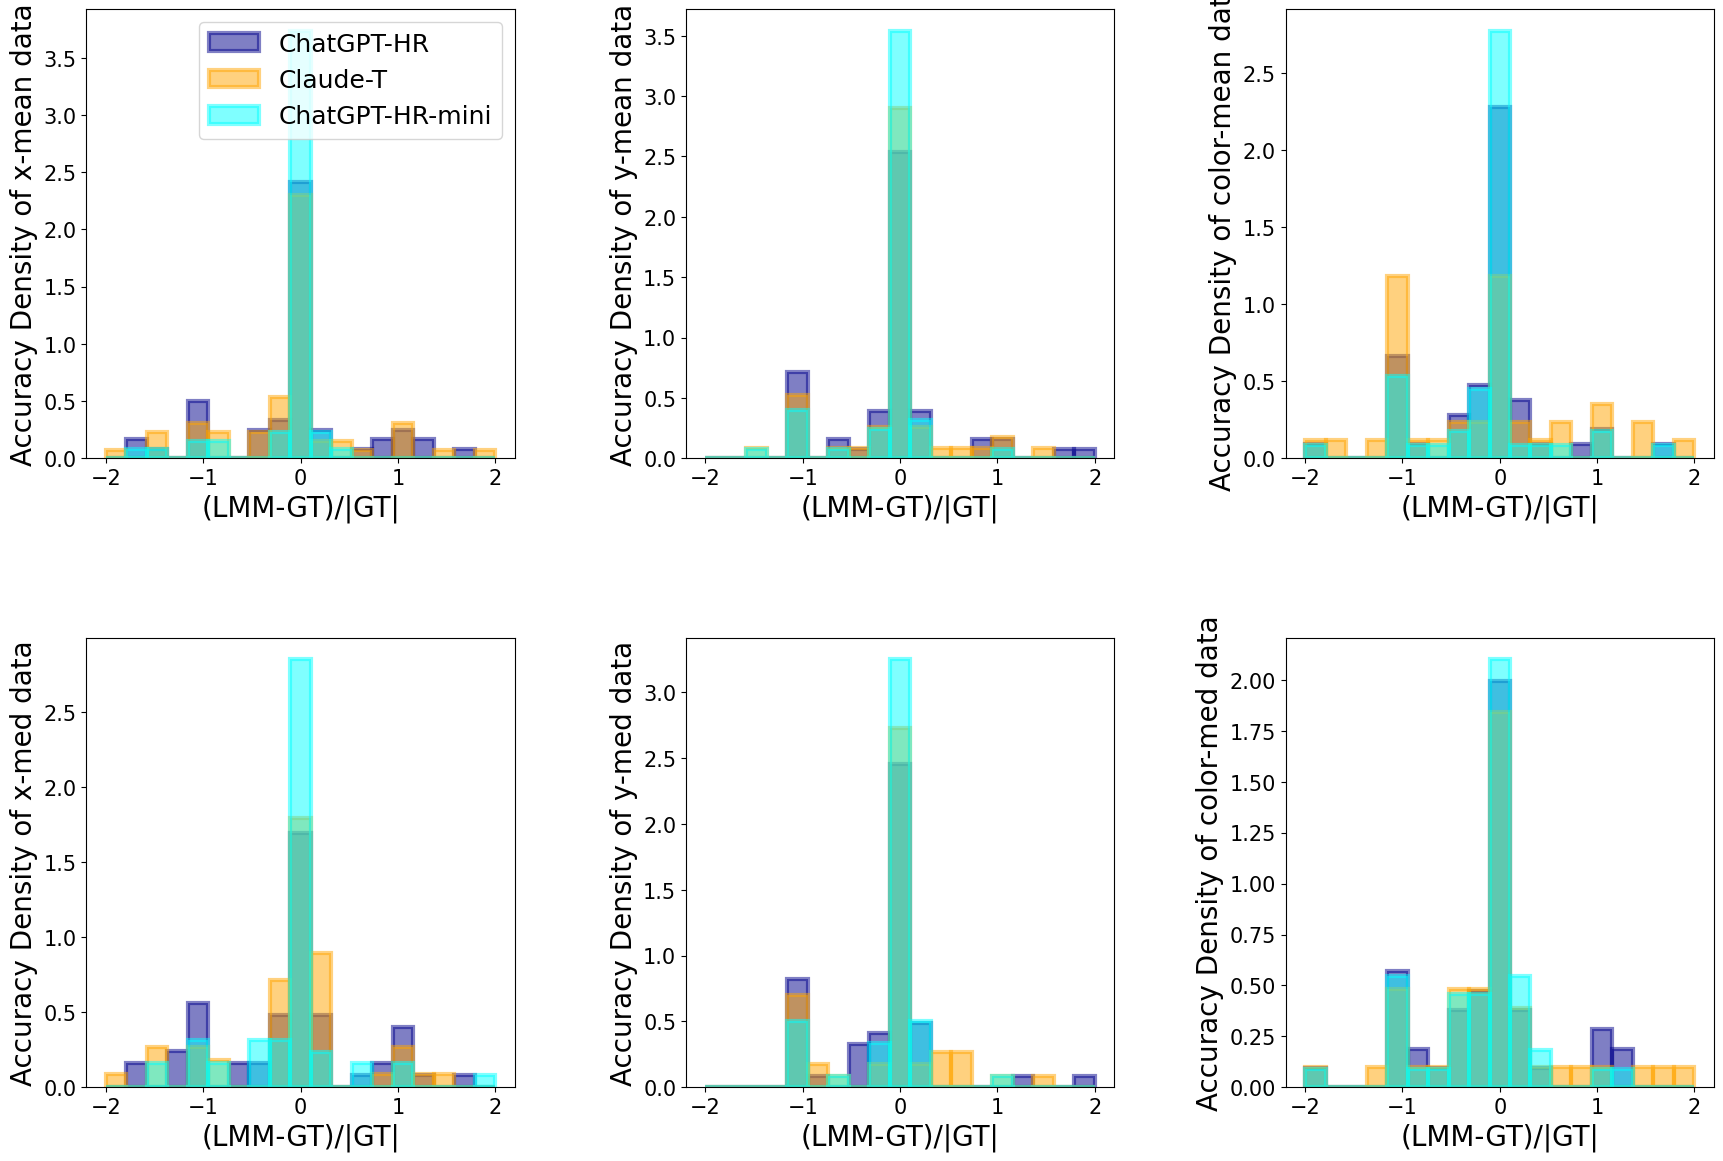

In [130]:
fig, axes = plot_specific_type(dfsubplot_sc, questions_figure_plots_contours, verbose=False)

In [131]:
qtest = 'What is the mean value of the data along the x-axis in this figure panel?'

for i,r in dfsubplot_sc[dfsubplot_sc['question']==qtest].iterrows():
    print(r['model'], r['LMM Answer'])

ChatGPT-HR {'mean x': -2.0}
ChatGPT-HR {'mean x': 14000.0}
ChatGPT-HR {'mean x': 0.0025}
ChatGPT-HR {'mean x': -2.5}
ChatGPT-HR {'mean x': 7.8}
ChatGPT-HR {'mean x': -3500.0}
ChatGPT-HR {'mean x': -10.0}
ChatGPT-HR {'mean x': -70.0}
ChatGPT-HR {'mean x': 112.75}
ChatGPT-HR {'mean x': 26.25}
ChatGPT-HR {'mean x': 5.4090909091}
ChatGPT-HR {'mean x': -50.0}
ChatGPT-HR {'mean x': 2.5}
ChatGPT-HR {'mean x': 0.7}
ChatGPT-HR {'mean x': -76500.0}
ChatGPT-HR {'mean x': 2.0}
ChatGPT-HR {'mean x': -45.75}
ChatGPT-HR {'mean x': 4780.0}
ChatGPT-HR {'mean x': [1850.0]}
ChatGPT-HR {'mean x': 275000.0}
ChatGPT-HR {'mean x': 0.0}
ChatGPT-HR {'mean x': [82500.0]}
ChatGPT-HR {'mean x': [5.0]}
ChatGPT-HR {'mean x': 10.25}
ChatGPT-HR {'mean x': 4.3}
ChatGPT-HR {'mean x': 400.0}
ChatGPT-HR {'mean x': [50.0, 100.0, 150.0, 200.0, 250.0, 300.0]}
ChatGPT-HR {'mean x': -68.0}
ChatGPT-HR {'mean x': 2.925}
ChatGPT-HR {'mean x': [-30.0, -30.0, -30.0, -30.0, -30.0, -30.0]}
ChatGPT-HR {'mean x': 2.55}
ChatGPT-HR {'me

In [132]:
dfsubplot[dfsubplot['question']==qtest]

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type,Explanation
49,Picture_000032_qa,3.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'mean x': 160.0},{'mean x': 132.89712763336416},Level 2,Plot-level questions,"{'explanation': 'In the fourth-row, left-most ..."
99,Picture_000031_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'mean x': 27.5},{'mean x': 27.691940867216925},Level 2,Plot-level questions,{'explanation': 'The x-axis tick labels shown ...
183,Picture_000089_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'mean x': 1500.0},{'mean x': 1503.1318170491734},Level 2,Plot-level questions,{'explanation': 'The x-axis (WAY) values used ...
565,Picture_000200_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'mean x': 1.0},{'mean x': 0.4874109192329842},Level 2,Plot-level questions,{'explanation': 'The panel’s x-axis (“SPIN”) s...
715,Picture_000065_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR,gpt-5.4-nano-2026-03-17,{'mean x': 27.0},{'mean x': 26.577641501268012},Level 2,Plot-level questions,{'explanation': 'The heatmap’s x-axis (“PAPER ...
...,...,...,...,...,...,...,...,...,...,...,...,...
16518,Picture_000176_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR-mini,gpt-5.4-mini-2026-03-17,{'mean x': 14.5},{'mean x': 15.406769130965131},Level 2,Plot-level questions,"{'explanation': 'In the second-row left panel,..."
16549,Picture_000110_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR-mini,gpt-5.4-mini-2026-03-17,{'mean x': 1.75},{'mean x': 1.771603715842001},Level 2,Plot-level questions,{'explanation': 'The x-axis data span appears ...
16582,Picture_000161_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR-mini,gpt-5.4-mini-2026-03-17,{'mean x': 1.0},{'mean x': 0.9890217284949184},Level 2,Plot-level questions,"{'explanation': 'In the second-row, second-col..."
16651,Picture_000033_qa,0.0,contour,What is the mean value of the data along the x...,False,ChatGPT-HR-mini,gpt-5.4-mini-2026-03-17,{'mean x': 150000000.0},{'mean x': 156116451.9886389},Level 2,Plot-level questions,{'explanation': 'The x-axis spans roughly 0.9 ...


### Lines

In [133]:
dfsubplot_l = df.copy()[df['plot type']=='line']

In [134]:
dfsubplot_l['question'].unique()

array(['What are the matplotlib linestyles in this figure panel?',
       'How many lines are there in the specified figure panel?',
       'What is the maximum value of the data along the x-axis in this figure panel?',
       'What is the mean value of the data along the x-axis in this figure panel?',
       'What is the median value of the data along the x-axis in this figure panel?',
       'What is the minimum value of the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the y-axis in this figure panel?',
       'What is the functional relationship between the x and y values in this figure panel?'],
      dtype=object)

In [135]:
# by number of item
questions_figure_plots_lines = [
    {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
    {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
]

df_question_tags_plots_lines = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags_plots_lines[t] = []

x-mean data
  the number of NaNs for model ChatGPT-HR = 30
  the number of NaNs for model Claude-T = 21
  the number of NaNs for model ChatGPT-HR-mini = 17
x-med data
  the number of NaNs for model ChatGPT-HR = 15
  the number of NaNs for model Claude-T = 43
  the number of NaNs for model ChatGPT-HR-mini = 50


/Users/jnaiman/LLM_VQA_MultiPanel/utils/results_plotting_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()   # now works without warnings


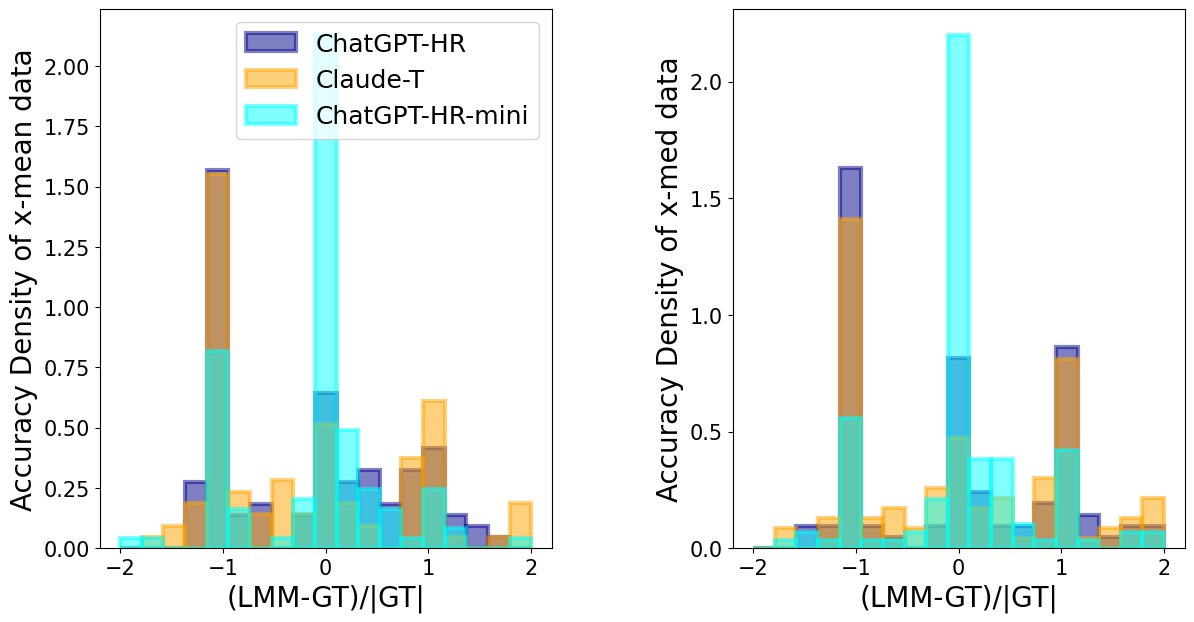

In [136]:
fig, axes = plot_specific_type(dfsubplot_l, questions_figure_plots_lines, verbose=False)

## Cross-figure

In [137]:
df[df['Level Type']=='Figure-level questions']['question'].unique()

array(['How many panels are in this figure?',
       'What is the plot style used in this figure?',
       'What is the colormap that was used in this figure?',
       'What is the aspect ratio of this figure?',
       'What are the titles for each figure panel?',
       'What are the x-axis titles for each figure panel?',
       'What are the y-axis titles for each figure panel?',
       'What are the values for each of the tick marks on the x-axis?',
       'What are the values for each of the tick marks on the y-axis?',
       'What are the plot types for each panel in the figure?',
       'Which plot shows the largest median data values?',
       'Which plot shows the strongest linear relationship between its x and y values?'],
      dtype=object)

In [138]:
# by number of item
questions_figure_cross = [
    {'tag':'strongest linear', 'question':'Which plot shows the strongest linear relationship between its x and y values?', 'type':'float', 'yfudge':2}, 
    {'tag':'largest median', 'question':'Which plot shows the largest median data values?', 'type':'float', 'yfudge':2}, 
    {'tag':'strongest linear (b)', 'question':'Which plot shows the strongest linear relationship between its x and y values?', 'type':'float', 'yfudge':50, 'norm':'binary diff'}, 
    {'tag':'largest median (b)', 'question':'Which plot shows the largest median data values?', 'type':'float', 'yfudge':50, 'norm':'binary diff'}, 
]

df_question_tags_cross = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags_cross[t] = []

[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align
[WARNING]: have to delete GT to align


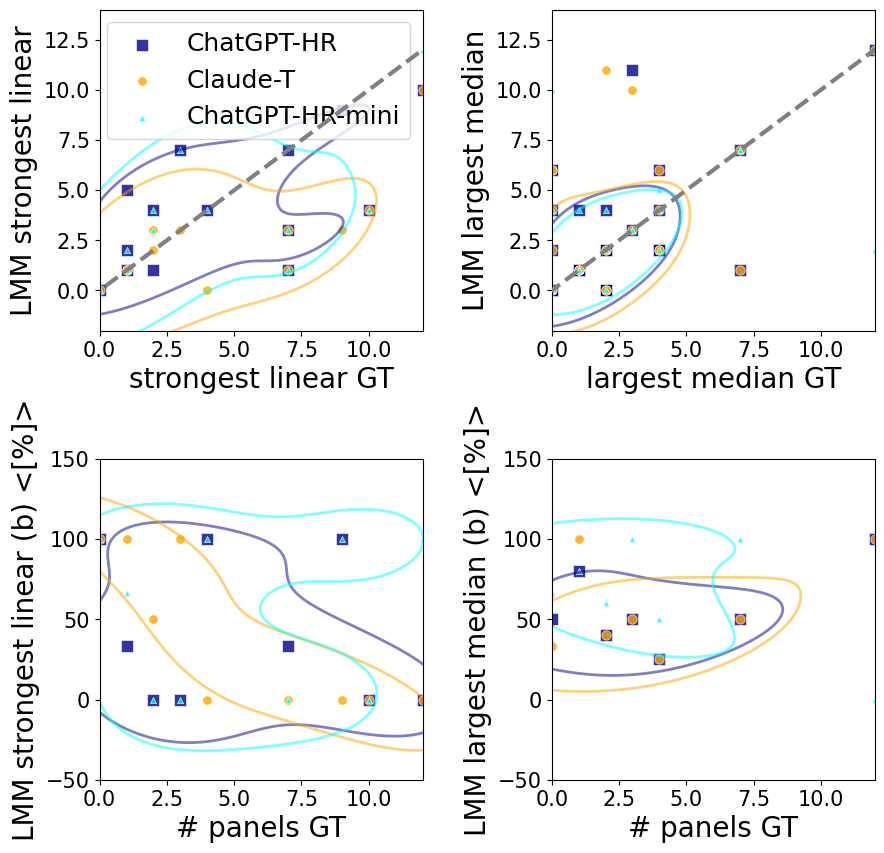

In [139]:
#ylims = {'# bars': (-100,100), '# scatters':(-100,100), '# lines':(-10,10)}
questions_plot = questions_figure_cross

diff_verses = '# panels GT'

import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)
from utils.parse_lmm_output_utils import get_lmm_gt, align_arrays_safe

base = 5
nx = 1; ny = 3
npanels = nx*ny
fig, axes = make_square_grid_figure_gs(len(questions_plot), figsize_per_plot=(base,base))

levels = [0.5]

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3

iqset = 0
plot_diffs = False
normalize_diff = False


for iq,q in enumerate(questions_plot):
    dfsub = df[df['question']==q['question']]
    for imodel, model in enumerate(dfsub['model'].unique()):
        dfsub2 = dfsub[dfsub['model']==model]
        gt, lmm1 = get_lmm_gt(dfsub2, q['type'])
        gttag = q['tag']+' GT'
        lmtag = labels[model]
        # if plot_diffs:
        #     lmm = (lmm1-gt)
        #     if normalize_diff:
        #         lmm = lmm/gt
        # else:
        lmm = deepcopy(lmm1)
        lmtag_adder = ''
        diffnorm = False
        binarydiff = False
        if 'norm' in q:
            if q['norm']=='diff':
                lmm = (lmm-gt)/np.abs(gt)
                lmtag_adder = ' (LMM-GT)/|GT|'
                diffnorm = True
            elif q['norm']=='binary diff':
                if diff_verses == '# panels GT':
                    gtp = []
                    for g in dfsub2['image id'].values:
                        with open(dir_jsons + g +'.json', 'r') as f:
                            dd = json.load(f)
                            dd = json.loads(dd)
                        dd = dd['figure']
                        gtp.append(dd['nrows']*dd['ncols'])
                    gttag = '# panels GT'
                    # now deposit diff binaries on gttag
                    if len(gt) > len(lmm):
                        lmm1 = align_arrays_safe(gt,lmm)
                    elif len(lmm) > len(gt):
                        gt = align_arrays_save(lmm,gt)
                    else:
                        lmm1 = lmm
                    lmm=[]
                    for g,l in zip(gt,lmm1):
                        if g == l:
                            lmm.append(1)
                        else:
                            lmm.append(0)
                    d = pd.DataFrame({gttag:gt, lmtag:lmm})
                    # deposit
                    gd = d.groupby(gttag)[lmtag].mean()
                    gt = gd.index; lmm = gd.values*100
                    lmtag_adder = " <[%]>"
                    binarydiff = True

        dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
        if iq == iqset:
            add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             labels[model], marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
        else:
            if not diffnorm:
                add_kde_contours(axes[iq], dfplot[gttag], dfplot[lmtag], colors[model], 
                             None, marker_styles[model], marker_sizes[model], 
                             levels=levels, plot_kde=plot_kde)
            else:
                diff = dfplot[lmtag]
                # count NaNs
                print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
                axes[iq].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                            color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                            linewidth=hist_thick)
                axes[iq].set_xlabel('(LMM-GT)/|GT|', fontsize=fontsize)
                axes[iq].set_ylabel('Accuracy Density of '+q['tag'],  fontsize=fontsize)
                axes[iq].legend()
    #if not plot_diffs:
    if 'yfudge' in q:
        if not diffnorm and not binarydiff:
            axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                        linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                        color=eq_linecolor)
            axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
        if binarydiff:
            axes[iq].set_ylim(0-q['yfudge'], 100+q['yfudge'])
        # else:
        #     axes[iq].set_ylim([q['xlim'][0]-q['yfudge'], q['xlim'][1]+q['yfudge']])
    if not diffnorm:
        axes[iq].set_xlim(np.min(gt), np.max(gt))
        axes[iq].set_ylabel('LMM ' + q['tag'] + lmtag_adder, fontsize=fontsize)
        axes[iq].set_xlabel(gttag, fontsize=fontsize)
    # if 'xscale' in q:
    #     axes[iq].set_xscale(q['xscale'])

axes[iqset].legend()


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)


In [140]:
gd

# panels GT
0.0     0.666667
1.0     0.800000
2.0     0.600000
3.0     1.000000
4.0     0.500000
7.0     1.000000
12.0    0.000000
Name: ChatGPT-HR-mini, dtype: float64

## Maybe a better way of doing binaries?

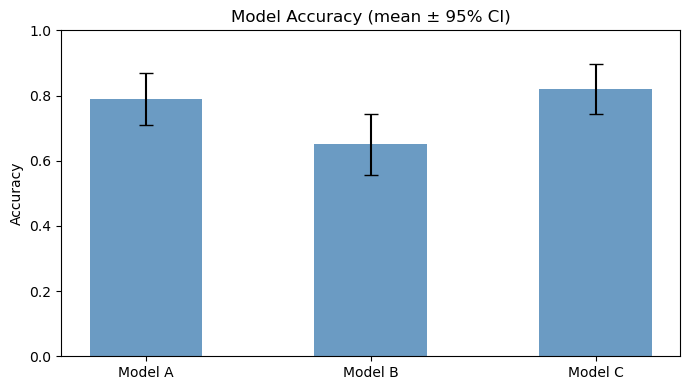

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

# Example data
results = {
    'Model A': np.random.binomial(1, 0.75, 100),
    'Model B': np.random.binomial(1, 0.60, 100),
    'Model C': np.random.binomial(1, 0.85, 100),
}

df = pd.DataFrame(results).melt(var_name='Model', value_name='Correct')

means = df.groupby('Model')['Correct'].mean()
n = df.groupby('Model')['Correct'].count()
# Wilson score CI or normal approx
ci = 1.96 * np.sqrt(means * (1 - means) / n)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(means.index, means.values, yerr=ci.values, capsize=5,
       color='steelblue', alpha=0.8, width=0.5)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title('Model Accuracy (mean ± 95% CI)')
plt.tight_layout()
plt.show()

<Axes: xlabel='Model', ylabel='Correct'>

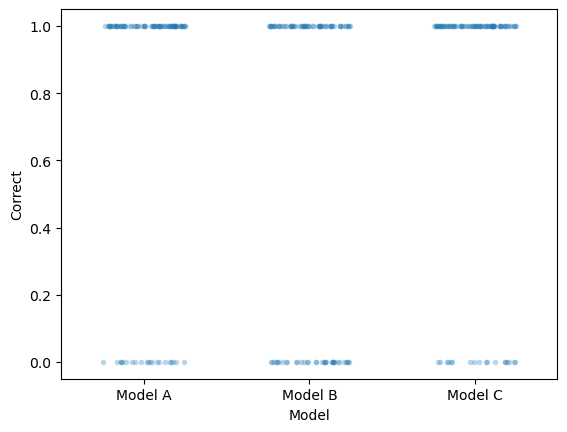

In [142]:
sns.stripplot(data=df, x='Model', y='Correct', jitter=0.25, alpha=0.3, size=4)

<Axes: >

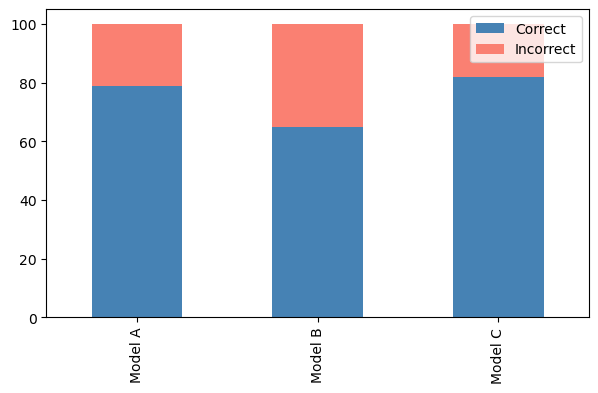

In [143]:
counts = pd.DataFrame({m: [v.sum(), len(v) - v.sum()] 
                        for m, v in results.items()}, 
                       index=['Correct', 'Incorrect'])
counts.T.plot(kind='bar', stacked=True, color=['steelblue','salmon'], figsize=(7,4))

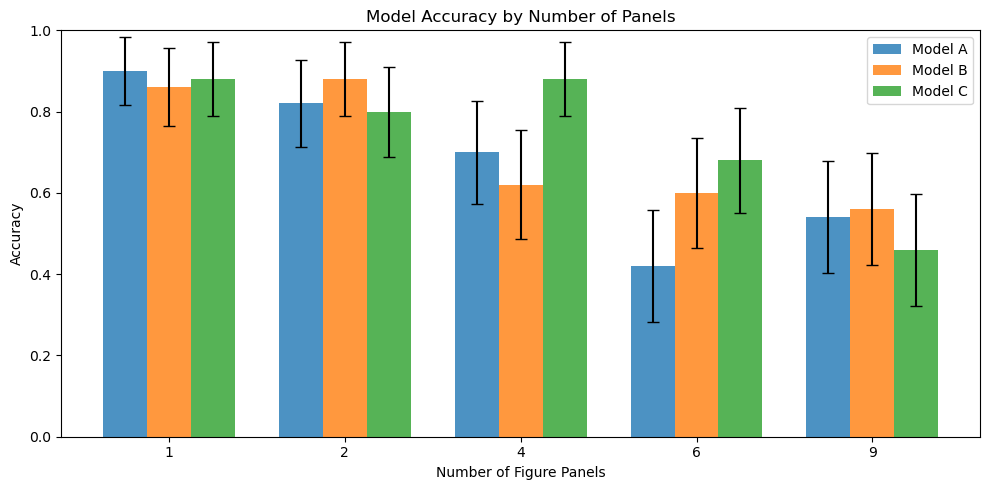

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Example data
np.random.seed(42)
models = ['Model A', 'Model B', 'Model C']
panel_counts = [1, 2, 4, 6, 9]

rows = []
for model in models:
    for n_panels in panel_counts:
        # accuracy tends to drop with more panels
        p = max(0.3, 0.9 - 0.05 * n_panels + np.random.normal(0, 0.05))
        responses = np.random.binomial(1, p, 50)
        rows.append({'Model': model, 'N_panels': n_panels,
                     'Accuracy': responses.mean(),
                     'CI': 1.96 * np.sqrt(responses.mean()*(1-responses.mean())/len(responses))})

df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(panel_counts))
width = 0.25

for i, model in enumerate(models):
    sub = df[df['Model'] == model]
    ax.bar(x + i*width, sub['Accuracy'], width=width, 
           yerr=sub['CI'], capsize=4, label=model, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(panel_counts)
ax.set_xlabel('Number of Figure Panels')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Model Accuracy by Number of Panels')
plt.tight_layout()

<Axes: xlabel='N_panels', ylabel='Model'>

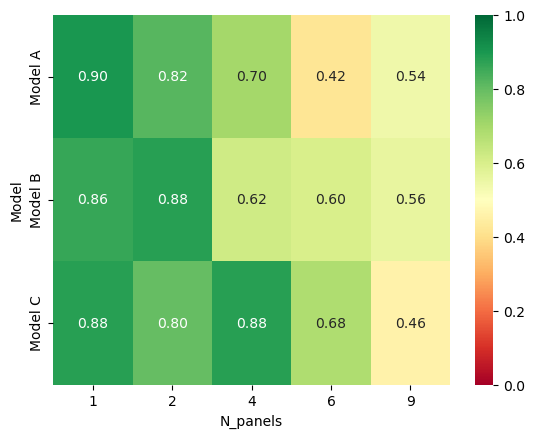

In [145]:
pivot = df.pivot(index='Model', columns='N_panels', values='Accuracy')
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)

In [146]:
df

,Model,N_panels,Accuracy,CI
0,Model A,1,0.90,0.083156
1,Model A,2,0.82,0.106491
2,Model A,4,0.70,0.127023
3,Model A,6,0.42,0.136807
4,Model A,9,0.54,0.138149
5,Model B,1,0.86,0.096180
6,Model B,2,0.88,0.090075
7,Model B,4,0.62,0.134542
8,Model B,6,0.60,0.135793
9,Model B,9,0.56,0.137591
